## GraphMD v2 finetuning notebook (binding affinity)

This notebook follows the same style as pretraining (`graphmd-v2.ipynb`) but switches the target to binding affinity (`logKa`) from `logKa.xlsx`.

- Uses train/val/test split files per MD shard (`train_test_val/MD_split_*_{train|val|test}.txt`).
- Loads pretrained model weights from `output/`.
- Streams over MD shard files one by one.
- Saves checkpoints regularly so training can resume if interrupted.


In [1]:
!pip install -q torch-geometric openpyxl pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/63.7 kB ? eta -:--:--


     ━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━ 41.0/63.7 kB 2.1 MB/s eta 0:00:01


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 891.8 kB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.3 MB ? eta -:--:--


   ━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/1.3 MB 5.0 MB/s eta 0:00:01


   ━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/1.3 MB 4.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 0.5/1.3 MB 5.2 MB/s eta 0:00:01


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━ 0.9/1.3 MB 6.7 MB/s eta 0:00:01


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.6 MB/s eta 0:00:00


In [ ]:
import os, sys, subprocess

REPO_URL = "https://github.com/Vaheshan/GraphMD.git"
TARGET_DIR = "/kaggle/working/project"
BRANCH = "Original"   # <-- change this

if "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
    if not os.path.exists(TARGET_DIR):
        print(f"Cloning repo from {REPO_URL} (branch: {BRANCH}) into {TARGET_DIR} ...")
        subprocess.run(
            ["git", "clone", "-b", BRANCH, "--single-branch", REPO_URL, TARGET_DIR],
            check=False
        )
    if TARGET_DIR not in sys.path:
        sys.path.append(TARGET_DIR)
    print("Repo path added to sys.path:", TARGET_DIR)
else:
    _here = os.path.abspath(os.getcwd())
    if _here not in sys.path:
        sys.path.insert(0, _here)
    print("Local mode: using sys.path[0] =", _here)

Cloning repo from https://github.com/Vaheshan/GraphMD.git into /kaggle/working/project ...


Cloning into '/kaggle/working/project'...


Repo path added to sys.path: /kaggle/working/project


In [ ]:
import os
import numpy as np
import pandas as pd
import h5py
from typing import List, Dict, Any, Tuple, Optional

import torch
from torch import Tensor

from graphs import (
    ProteinGraphBuilder,
    CorrelationEdgeBuilder,
    PocketGraphBuilder,
    ProteinGraphInputs,
    PocketGraphInputs,
)
from models import MultiscaleMDGNN
from training.batch_utils import collate_complexes
from training.trainer import Trainer
from training.qm_feature_utils import (
    build_qm_feature_table,
    make_qm_tensor_for_batch,
    load_selected_features_from_correlation_csv,
)
from training.checkpoint_utils import load_state_dict_shape_safe

print('Imports done.')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# -------------------------------------------------------------------
# Paths / config
# -------------------------------------------------------------------
ROOT_DIR = '/kaggle/input/datasets/uom210636r/misato'
RAW_DIR = ROOT_DIR
SPLIT_DIR = os.path.join(ROOT_DIR, 'train_test_val')
# Filtered split files: MD_split_1_test_filtered.txt, MD_split_1_train_filtered.txt, ...
FILTERED_SPLIT_DIR = os.path.join(ROOT_DIR, 'filtered_files')  # TODO update on Kaggle
USE_FILTERED_SPLITS = True
AFFINITY_XLSX_PATH = '/kaggle/working/project/logKa.xlsx'  # TODO update on Kaggle
QM_H5_PATH = '/kaggle/input/your-qm-dataset/qm_features.h5'  # TODO update on Kaggle
QM_NORM_H5_PATH = '/kaggle/input/your-qm-dataset/qm_norm.h5'  # optional, used by analysis script
QM_CORRELATION_CSV_PATH = '/kaggle/working/qm_affinity_correlations.csv'  # TODO update on Kaggle
QM_FEATURE_MIN_ABS_CORR = 0.15
QM_FEATURE_TOP_K = None  # set int to cap selected features
USE_QM_FEATURES_FOR_FINETUNE = True

MD_HDF5_FILES = []
for fname in sorted(os.listdir(RAW_DIR)):
    if fname.lower().startswith('md_split_') and fname.lower().endswith('.hdf5'):
        MD_HDF5_FILES.append(os.path.join(RAW_DIR, fname))

print('Found MD HDF5 files:')
for p in MD_HDF5_FILES:
    print('  ', p)

# Finetuning outputs/checkpoints
PRETRAINED_MODEL_PATH = '/kaggle/working/project/output/multiscale_mdg_nn_pretrained.pth'
FINETUNE_CKPT_PATH = '/kaggle/working/multiscale_mdg_nn_finetune_checkpoint.pth'
BEST_FINETUNE_PATH = '/kaggle/working/multiscale_mdg_nn_finetune_best_val.pth'
FINAL_FINETUNE_PATH = '/kaggle/working/multiscale_mdg_nn_finetuned.pth'

# Training hyperparameters
N_FRAMES_FOR_PROTEIN_DYNAMICS = 30
POCKET_CUTOFF = 6.0
ATOM_FEATURE_DIM = 128

BATCH_SIZE = 2
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
CHECKPOINT_INTERVAL = 100

MAX_TRAIN_COMPLEXES_PER_FILE = None
MAX_VAL_COMPLEXES_PER_FILE = None
MAX_TEST_COMPLEXES_PER_FILE = None

print('Config set.')


Imports done.
Using device: cuda
Found MD HDF5 files:
   /kaggle/input/datasets/uom210636r/misato/MD_split_1.hdf5
   /kaggle/input/datasets/uom210636r/misato/MD_split_10.hdf5
   /kaggle/input/datasets/uom210636r/misato/MD_split_2.hdf5
   /kaggle/input/datasets/uom210636r/misato/MD_split_3.hdf5
   /kaggle/input/datasets/uom210636r/misato/MD_split_4.hdf5
   /kaggle/input/datasets/uom210636r/misato/MD_split_5.hdf5
   /kaggle/input/datasets/uom210636r/misato/MD_split_6.hdf5
   /kaggle/input/datasets/uom210636r/misato/MD_split_7.hdf5
   /kaggle/input/datasets/uom210636r/misato/MD_split_8.hdf5
   /kaggle/input/datasets/uom210636r/misato/MD_split_9.hdf5
Config set.


In [4]:
# -------------------------------------------------------------------
# Helpers: splits, labels, graph builders
# -------------------------------------------------------------------

def base_name_from_md_path(md_hdf5_path: str) -> str:
    return os.path.splitext(os.path.basename(md_hdf5_path))[0]


def load_split_ids(md_hdf5_path: str, split_type: str) -> List[str]:
    base_name = base_name_from_md_path(md_hdf5_path)

    # Prefer filtered split files when requested.
    # Example: MD_split_1_test_filtered.txt
    filtered_txt = os.path.join(FILTERED_SPLIT_DIR, f'{base_name}_{split_type}_filtered.txt')
    default_txt = os.path.join(SPLIT_DIR, f'{base_name}_{split_type}.txt')

    if USE_FILTERED_SPLITS:
        if not os.path.exists(filtered_txt):
            raise FileNotFoundError(
                f'Filtered split file not found: {filtered_txt}'
            )
        txt_file = filtered_txt
    else:
        if not os.path.exists(default_txt):
            raise FileNotFoundError(
                f'Default split file not found: {default_txt}'
            )
        txt_file = default_txt

    with open(txt_file, 'r') as f:
        ids = [line.strip() for line in f if line.strip()]
    print(f'Loaded {len(ids)} PDB IDs from {txt_file}')
    return ids


def normalize_pdb_id(pid: str) -> str:
    return str(pid).strip().upper()


def build_hdf5_key_map(h5_file: h5py.File) -> Dict[str, str]:
    """Map normalized PDB IDs -> actual HDF5 keys."""
    mapping: Dict[str, str] = {}
    for k in h5_file.keys():
        nk = normalize_pdb_id(k)
        if nk not in mapping:
            mapping[nk] = k
    return mapping


def select_frame_indices(num_frames: int, n_select: int) -> List[int]:
    if n_select >= num_frames:
        return list(range(num_frames))
    idx = np.linspace(0, num_frames - 1, n_select, dtype=int)
    return sorted(set(idx.tolist()))


def load_affinity_map(xlsx_path: str) -> Dict[str, float]:
    if not os.path.exists(xlsx_path):
        raise FileNotFoundError(f'Affinity file not found: {xlsx_path}')

    df = pd.read_excel(xlsx_path)
    if 'PDBID' not in df.columns or 'logKa' not in df.columns:
        raise ValueError('logKa.xlsx must contain columns: PDBID, logKa')

    # Keep only required columns, coerce invalid values, and filter to finite targets.
    df = df[['PDBID', 'logKa']].copy()
    df['logKa'] = pd.to_numeric(df['logKa'], errors='coerce')

    valid_mask = df['PDBID'].notna() & df['logKa'].notna() & np.isfinite(df['logKa'].to_numpy())
    df = df.loc[valid_mask].copy()

    df['PDBID'] = df['PDBID'].astype(str).str.strip().str.upper()

    # If duplicates exist, keep the first occurrence after filtering.
    df = df.drop_duplicates(subset=['PDBID'], keep='first')

    aff_map = {row.PDBID: float(row.logKa) for row in df.itertuples(index=False)}
    print(f'Loaded affinity labels (finite only): {len(aff_map)}')
    return aff_map


def build_residue_trajectories(
    misato_grp: h5py.Group,
    frame_indices: List[int],
) -> Tuple[Tensor, Tensor, np.ndarray]:
    traj = misato_grp['trajectory_coordinates'][frame_indices, :, :]  # (T_sel, A, 3)
    T_sel, num_atoms, _ = traj.shape

    ligand_begin = int(misato_grp['molecules_begin_atom_index'][:][-1])
    protein_len = ligand_begin

    residue_idx = misato_grp['atoms_residue'][:protein_len]
    _, inverse = np.unique(residue_idx, return_inverse=True)
    R = int(inverse.max()) + 1 if inverse.size > 0 else 0

    coords0 = traj[0, :protein_len, :]
    centroids0 = np.zeros((R, 3), dtype=np.float32)
    for r in range(R):
        mask_r = inverse == r
        centroids0[r] = coords0[mask_r].mean(axis=0)

    offset_N = np.array([0.5, 0.0, 0.0], dtype=np.float32)
    offset_C = np.array([0.0, 0.5, 0.0], dtype=np.float32)
    backbone_coords = np.stack([centroids0 + offset_N, centroids0, centroids0 + offset_C], axis=1)

    md_res = np.zeros((T_sel, R, 3), dtype=np.float32)
    for t in range(T_sel):
        coords_t = traj[t, :protein_len, :]
        for r in range(R):
            mask_r = inverse == r
            md_res[t, r] = coords_t[mask_r].mean(axis=0)

    atom_to_residue_full = -np.ones(num_atoms, dtype=np.int64)
    atom_to_residue_full[:protein_len] = inverse

    return torch.from_numpy(backbone_coords).float(), torch.from_numpy(md_res).float(), atom_to_residue_full


def build_pocket_graph_for_frame(
    misato_grp: h5py.Group,
    frame_index: int,
    atom_to_residue_full: np.ndarray,
    pocket_builder: PocketGraphBuilder,
    pocket_cutoff: float,
    atom_feature_dim: int,
) -> Any:
    coords_t = misato_grp['trajectory_coordinates'][frame_index, :, :]  # (A, 3)
    num_atoms = coords_t.shape[0]
    atom_numbers = misato_grp['atoms_number'][:]
    ligand_begin = int(misato_grp['molecules_begin_atom_index'][:][-1])

    ligand_mask_global = np.arange(num_atoms) >= ligand_begin
    heavy_atom_mask = atom_numbers != 1
    ligand_mask_global = ligand_mask_global & heavy_atom_mask

    ligand_indices = np.where(ligand_mask_global)[0]
    if ligand_indices.size == 0:
        pocket_indices = np.arange(num_atoms)
    else:
        ligand_coords = coords_t[ligand_indices]
        ligand_centroid = ligand_coords.mean(axis=0, keepdims=True)
        dists_to_ligand = np.linalg.norm(coords_t - ligand_centroid, axis=1)
        pocket_mask = dists_to_ligand <= pocket_cutoff
        pocket_indices = np.where(pocket_mask | ligand_mask_global)[0]

    coords_pocket = torch.from_numpy(coords_t[pocket_indices].astype(np.float32))
    atom_nums_pocket = atom_numbers[pocket_indices].astype(np.int64)
    atom_idx = atom_nums_pocket - 1
    atom_idx[atom_idx < 0] = 0
    atom_idx[atom_idx >= atom_feature_dim] = atom_feature_dim - 1
    atom_features = torch.nn.functional.one_hot(torch.from_numpy(atom_idx), num_classes=atom_feature_dim).float()

    atom_is_ligand = torch.from_numpy(ligand_mask_global[pocket_indices].astype(np.bool_))

    atom_to_residue = []
    for idx in pocket_indices:
        if ligand_mask_global[idx]:
            atom_to_residue.append(-1)
        else:
            atom_to_residue.append(int(atom_to_residue_full[idx]))
    atom_to_residue_t = torch.tensor(atom_to_residue, dtype=torch.long)

    pocket_inputs = PocketGraphInputs(
        atom_coords=coords_pocket,
        atom_features=atom_features,
        atom_is_ligand=atom_is_ligand,
        atom_to_residue=atom_to_residue_t,
    )
    return pocket_builder(pocket_inputs)


def most_stable_frame_index(misato_grp: h5py.Group) -> int:
    rmsd = misato_grp['frames_rmsd_ligand'][:]
    return int(np.argmin(rmsd))


def evaluate_split(
    model: MultiscaleMDGNN,
    affinity_map: Dict[str, float],
    split_type: str,
    max_per_file: Optional[int] = None,
) -> float:
    model.eval()
    losses = []
    mse = torch.nn.MSELoss()

    protein_builder = ProteinGraphBuilder()
    corr_builder = CorrelationEdgeBuilder()
    pocket_builder = PocketGraphBuilder()

    with torch.no_grad():
        for md_path in MD_HDF5_FILES:
            split_ids = load_split_ids(md_path, split_type)
            if max_per_file is not None:
                split_ids = split_ids[:max_per_file]
            with h5py.File(md_path, 'r') as f:
                h5_key_map = build_hdf5_key_map(f)

                # Keep pairs of (split_id, actual_hdf5_key) where label exists.
                filtered_pairs = []
                for pid in split_ids:
                    npid = normalize_pdb_id(pid)
                    if npid in h5_key_map and npid in affinity_map:
                        filtered_pairs.append((pid, h5_key_map[npid]))

                for start in range(0, len(filtered_pairs), BATCH_SIZE):
                    pairs_batch = filtered_pairs[start:start + BATCH_SIZE]
                    protein_graphs = []
                    pocket_graphs = []
                    y_aff = []
                    batch_pdb_ids = []

                    for split_pid, h5_key in pairs_batch:
                        grp = f[h5_key]
                        frame_indices = select_frame_indices(grp['trajectory_coordinates'].shape[0], N_FRAMES_FOR_PROTEIN_DYNAMICS)
                        backbone_coords, md_res_coords, atom_to_residue_full = build_residue_trajectories(grp, frame_indices)

                        protein_inputs = ProteinGraphInputs(backbone_coords=backbone_coords, md_residue_coords=md_res_coords)
                        p_graph = protein_builder(protein_inputs)
                        p_graph = corr_builder.add_correlation_edges(p_graph, md_res_coords)

                        best_t = most_stable_frame_index(grp)
                        a_graph = build_pocket_graph_for_frame(
                            grp, best_t, atom_to_residue_full, pocket_builder,
                            POCKET_CUTOFF, ATOM_FEATURE_DIM
                        )

                        protein_graphs.append(p_graph)
                        pocket_graphs.append(a_graph)
                        npid = normalize_pdb_id(split_pid)
                        batch_pdb_ids.append(npid)
                        y_aff.append(torch.tensor(affinity_map[npid], dtype=torch.float32))

                    if not protein_graphs:
                        continue

                    labels = {'y_affinity': torch.stack(y_aff)}
                    if USE_QM_FEATURES_FOR_FINETUNE:
                        labels['qm_features'] = make_qm_tensor_for_batch(
                            batch_pdb_ids,
                            qm_feature_table,
                            QM_FEATURE_DIM,
                        )

                    gbatch = collate_complexes(protein_graphs, pocket_graphs, labels)
                    gbatch = trainer._move_graph_batch(gbatch)
                    model_inputs = {'protein': gbatch.protein, 'pocket': gbatch.pocket}
                    if USE_QM_FEATURES_FOR_FINETUNE:
                        model_inputs['qm_features'] = gbatch.labels['qm_features']
                    out = model(model_inputs, return_latent=False)
                    y_pred = out['y_pred'].view(-1)
                    y_true = gbatch.labels['y_affinity'].view(-1)
                    loss = mse(y_pred, y_true)
                    losses.append(float(loss.item()))

    model.train()
    return float(np.mean(losses)) if losses else float('nan')


print('Helpers ready.')


Helpers ready.


In [5]:
# -------------------------------------------------------------------
# Build model, load pretrained weights + checkpoint resume
# -------------------------------------------------------------------

if not MD_HDF5_FILES:
    raise RuntimeError('No MD split files found.')

affinity_map = load_affinity_map(AFFINITY_XLSX_PATH)

qm_feature_table = {}
qm_feature_names = []
QM_FEATURE_DIM = 0
if USE_QM_FEATURES_FOR_FINETUNE:
    if not os.path.exists(QM_H5_PATH):
        raise FileNotFoundError(f'QM_H5_PATH not found: {QM_H5_PATH}')

    all_split_pdb_ids = []
    for md_path in MD_HDF5_FILES:
        for split_type in ('train', 'val', 'test'):
            all_split_pdb_ids.extend(load_split_ids(md_path, split_type))

    all_split_pdb_ids = sorted({normalize_pdb_id(pid) for pid in all_split_pdb_ids})

    selected_qm_feature_names = None
    if os.path.exists(QM_CORRELATION_CSV_PATH):
        selected_qm_feature_names = load_selected_features_from_correlation_csv(
            QM_CORRELATION_CSV_PATH,
            min_abs_corr=QM_FEATURE_MIN_ABS_CORR,
            top_k=QM_FEATURE_TOP_K,
        )
        print(
            f'Selected {len(selected_qm_feature_names)} QM features from correlation CSV '
            f'(min_abs_corr={QM_FEATURE_MIN_ABS_CORR}, top_k={QM_FEATURE_TOP_K}).'
        )
    else:
        print('Correlation CSV not found; using all available QM features.')

    qm_feature_table, qm_feature_names = build_qm_feature_table(
        QM_H5_PATH,
        all_split_pdb_ids,
        selected_feature_names=selected_qm_feature_names,
    )
    QM_FEATURE_DIM = len(qm_feature_names)
    if QM_FEATURE_DIM == 0:
        raise RuntimeError('QM feature extraction returned zero features.')
    print(f'QM feature vectors ready: {len(qm_feature_table)} molecules, dim={QM_FEATURE_DIM}')
else:
    print('QM feature branch disabled; running baseline finetuning path.')

model = MultiscaleMDGNN(
    atom_feature_dim=ATOM_FEATURE_DIM,
    use_qm_features_for_finetune=USE_QM_FEATURES_FOR_FINETUNE,
    qm_feature_dim=QM_FEATURE_DIM,
)
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = Trainer(model=model, optimizer=optimizer, lambda_temp=0.0, alpha_multitask=0.0, device=device)

start_epoch = 0
global_step = 0
best_val = float('inf')

if os.path.exists(FINETUNE_CKPT_PATH):
    print(f'Found finetune checkpoint at {FINETUNE_CKPT_PATH}, loading...')
    ckpt = torch.load(FINETUNE_CKPT_PATH, map_location=device)
    load_msg, skipped = load_state_dict_shape_safe(model, ckpt['model_state'], strict=False)
    if skipped:
        print(f'Checkpoint load: skipped {len(skipped)} keys with shape mismatch (e.g. head after QM branch).')
    print('Checkpoint load -> missing:', load_msg.missing_keys, 'unexpected:', load_msg.unexpected_keys)
    try:
        optimizer.load_state_dict(ckpt['optim_state'])
    except Exception as e:
        print('Optimizer state not loaded due to mismatch:', e)
    start_epoch = int(ckpt.get('epoch', 0))
    global_step = int(ckpt.get('global_step', 0))
    best_val = float(ckpt.get('best_val', best_val))
    print(f'Resumed from epoch={start_epoch}, global_step={global_step}, best_val={best_val:.5f}')
elif os.path.exists(PRETRAINED_MODEL_PATH):
    print(f'Loading pretrained model from {PRETRAINED_MODEL_PATH} ...')
    pre = torch.load(PRETRAINED_MODEL_PATH, map_location=device)
    load_msg, skipped = load_state_dict_shape_safe(model, pre, strict=False)
    if skipped:
        print(f'Pretrained load: skipped {len(skipped)} keys with shape mismatch (e.g. head after QM branch).')
    print('Pretrained load -> missing:', load_msg.missing_keys, 'unexpected:', load_msg.unexpected_keys)
else:
    print('WARNING: No pretrained model found; finetuning will start from random init.')


Loaded affinity labels (finite only): 16470


Loading pretrained model from /kaggle/working/project/output/multiscale_mdg_nn_pretrained.pth ...


Target diagnostics for logKa.xlsx
--------------------------------
Total rows: 16470
Missing PDBID: 0
Missing logKa: 0
Non-numeric logKa (after coercion): 0
Non-finite logKa (+/-inf): 0
Valid unique labels used: 16470
logKa mean: 6.42587
logKa median: 6.51928


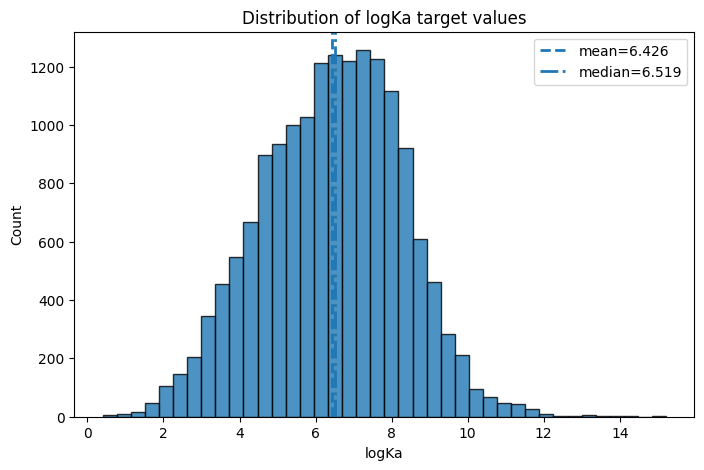

Loaded 1162 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_1_train_filtered.txt


Loaded 1156 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_10_train_filtered.txt


Loaded 1145 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_2_train_filtered.txt


Loaded 1150 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_3_train_filtered.txt


Loaded 1153 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_4_train_filtered.txt


...

Loaded 246 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_6_test_filtered.txt


Loaded 245 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_7_test_filtered.txt


Loaded 250 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_8_test_filtered.txt


Loaded 250 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_9_test_filtered.txt


test: 2472/2472 ids have valid logKa labels (100.00%)


In [6]:
# -------------------------------------------------------------------
# Target diagnostics: missing/non-finite checks + distribution stats
# -------------------------------------------------------------------
import matplotlib.pyplot as plt

raw_aff_df = pd.read_excel(AFFINITY_XLSX_PATH)
if 'PDBID' not in raw_aff_df.columns or 'logKa' not in raw_aff_df.columns:
    raise ValueError('logKa.xlsx must contain columns: PDBID, logKa')

diag_df = raw_aff_df[['PDBID', 'logKa']].copy()
diag_df['logKa_num'] = pd.to_numeric(diag_df['logKa'], errors='coerce')

missing_pdbid = diag_df['PDBID'].isna().sum()
missing_logka = diag_df['logKa'].isna().sum()
non_numeric_logka = diag_df['logKa_num'].isna().sum() - missing_logka
non_finite_logka = (~np.isfinite(diag_df['logKa_num'].to_numpy())).sum() - diag_df['logKa_num'].isna().sum()

valid_mask = diag_df['PDBID'].notna() & diag_df['logKa_num'].notna() & np.isfinite(diag_df['logKa_num'].to_numpy())
valid_df = diag_df.loc[valid_mask].copy()
valid_df['PDBID'] = valid_df['PDBID'].astype(str).str.strip().str.upper()
valid_df = valid_df.drop_duplicates(subset=['PDBID'], keep='first')

print('Target diagnostics for logKa.xlsx')
print('--------------------------------')
print(f'Total rows: {len(diag_df)}')
print(f'Missing PDBID: {missing_pdbid}')
print(f'Missing logKa: {missing_logka}')
print(f'Non-numeric logKa (after coercion): {max(non_numeric_logka, 0)}')
print(f'Non-finite logKa (+/-inf): {max(non_finite_logka, 0)}')
print(f'Valid unique labels used: {len(valid_df)}')

logka_vals = valid_df['logKa_num'].to_numpy(dtype=np.float32)
print(f'logKa mean: {float(np.mean(logka_vals)):.5f}')
print(f'logKa median: {float(np.median(logka_vals)):.5f}')

plt.figure(figsize=(8, 5))
plt.hist(logka_vals, bins=40, alpha=0.8, edgecolor='black')
plt.axvline(np.mean(logka_vals), linestyle='--', linewidth=2, label=f"mean={np.mean(logka_vals):.3f}")
plt.axvline(np.median(logka_vals), linestyle='-.', linewidth=2, label=f"median={np.median(logka_vals):.3f}")
plt.title('Distribution of logKa target values')
plt.xlabel('logKa')
plt.ylabel('Count')
plt.legend()
plt.show()

# Optional coverage check: how many split IDs actually have valid labels
for split_name in ['train', 'val', 'test']:
    total_ids = 0
    matched_ids = 0
    for md_path in MD_HDF5_FILES:
        ids = load_split_ids(md_path, split_name)
        total_ids += len(ids)
        matched_ids += sum(1 for pid in ids if pid.upper() in set(valid_df['PDBID']))
    ratio = matched_ids / total_ids if total_ids else 0.0
    print(f'{split_name}: {matched_ids}/{total_ids} ids have valid logKa labels ({ratio:.2%})')

In [7]:
# -------------------------------------------------------------------
# Per-file coverage audit: where IDs are dropped
# -------------------------------------------------------------------

def audit_split_coverage(affinity_map: Dict[str, float], split_name: str) -> None:
    print(f"\n=== Coverage audit: {split_name} ===")
    total_split = 0
    total_in_hdf5 = 0
    total_with_label = 0
    total_usable = 0

    for md_path in MD_HDF5_FILES:
        base = base_name_from_md_path(md_path)
        split_ids = load_split_ids(md_path, split_name)
        n_split = len(split_ids)

        with h5py.File(md_path, 'r') as f:
            h5_key_map = build_hdf5_key_map(f)
            in_hdf5_ids = [pid for pid in split_ids if normalize_pdb_id(pid) in h5_key_map]
            with_label_ids = [pid for pid in split_ids if normalize_pdb_id(pid) in affinity_map]
            usable_ids = [pid for pid in split_ids if (normalize_pdb_id(pid) in h5_key_map and normalize_pdb_id(pid) in affinity_map)]

        n_hdf5 = len(in_hdf5_ids)
        n_label = len(with_label_ids)
        n_usable = len(usable_ids)

        total_split += n_split
        total_in_hdf5 += n_hdf5
        total_with_label += n_label
        total_usable += n_usable

        pct_hdf5 = (n_hdf5 / n_split * 100.0) if n_split else 0.0
        pct_label = (n_label / n_split * 100.0) if n_split else 0.0
        pct_usable = (n_usable / n_split * 100.0) if n_split else 0.0

        print(
            f"{base:>12} | split={n_split:4d} | in_hdf5={n_hdf5:4d} ({pct_hdf5:6.2f}%) "
            f"| with_label={n_label:4d} ({pct_label:6.2f}%) | usable={n_usable:4d} ({pct_usable:6.2f}%)"
        )

    pct_hdf5_total = (total_in_hdf5 / total_split * 100.0) if total_split else 0.0
    pct_label_total = (total_with_label / total_split * 100.0) if total_split else 0.0
    pct_usable_total = (total_usable / total_split * 100.0) if total_split else 0.0

    print('-' * 95)
    print(
        f"{'TOTAL':>12} | split={total_split:4d} | in_hdf5={total_in_hdf5:4d} ({pct_hdf5_total:6.2f}%) "
        f"| with_label={total_with_label:4d} ({pct_label_total:6.2f}%) | usable={total_usable:4d} ({pct_usable_total:6.2f}%)"
    )


# Run for all splits
for split in ['train', 'val', 'test']:
    audit_split_coverage(affinity_map, split)

# Optional: inspect a few IDs that fail label matching but exist in HDF5
# to detect formatting mismatches.
md0 = MD_HDF5_FILES[0]
ids0 = load_split_ids(md0, 'train')
with h5py.File(md0, 'r') as f0:
    h5_key_map0 = build_hdf5_key_map(f0)
    missing_label_examples = [
        pid for pid in ids0
        if (normalize_pdb_id(pid) in h5_key_map0 and normalize_pdb_id(pid) not in affinity_map)
    ][:20]

print("\nSample IDs in HDF5 but missing in affinity_map (first file):")
print(missing_label_examples)

print("\nTip: If these look like formatting variants (suffixes/case/whitespace), normalize both split IDs and label PDBIDs with the same rule.")


=== Coverage audit: train ===
Loaded 1162 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_1_train_filtered.txt


  MD_split_1 | split=1162 | in_hdf5=1162 (100.00%) | with_label=1162 (100.00%) | usable=1162 (100.00%)
Loaded 1156 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_10_train_filtered.txt


 MD_split_10 | split=1156 | in_hdf5=1156 (100.00%) | with_label=1156 (100.00%) | usable=1156 (100.00%)
Loaded 1145 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_2_train_filtered.txt


  MD_split_2 | split=1145 | in_hdf5=1145 (100.00%) | with_label=1145 (100.00%) | usable=1145 (100.00%)
Loaded 1150 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_3_train_filtered.txt


  MD_split_3 | split=1150 | in_hdf5=1150 (100.00%) | with_label=1150 (100.00%) | usable=1150 (100.00%)
Loaded 1153 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_4_train_filtered.txt


...

  MD_split_6 | split= 246 | in_hdf5= 246 (100.00%) | with_label= 246 (100.00%) | usable= 246 (100.00%)
Loaded 245 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_7_test_filtered.txt


  MD_split_7 | split= 245 | in_hdf5= 245 (100.00%) | with_label= 245 (100.00%) | usable= 245 (100.00%)
Loaded 250 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_8_test_filtered.txt


  MD_split_8 | split= 250 | in_hdf5= 250 (100.00%) | with_label= 250 (100.00%) | usable= 250 (100.00%)
Loaded 250 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_9_test_filtered.txt


  MD_split_9 | split= 250 | in_hdf5= 250 (100.00%) | with_label= 250 (100.00%) | usable= 250 (100.00%)
-----------------------------------------------------------------------------------------------
       TOTAL | split=2472 | in_hdf5=2472 (100.00%) | with_label=2472 (100.00%) | usable=2472 (100.00%)
Loaded 1162 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_1_train_filtered.txt



Sample IDs in HDF5 but missing in affinity_map (first file):
[]

Tip: If these look like formatting variants (suffixes/case/whitespace), normalize both split IDs and label PDBIDs with the same rule.


In [8]:
# -------------------------------------------------------------------
# Finetuning loop (train + val), with checkpoints
# -------------------------------------------------------------------

print('Starting finetuning...')
for epoch in range(start_epoch, NUM_EPOCHS):
    print(f'\n===== Epoch {epoch + 1}/{NUM_EPOCHS} =====')
    epoch_train_losses = []

    protein_builder = ProteinGraphBuilder()
    corr_builder = CorrelationEdgeBuilder()
    pocket_builder = PocketGraphBuilder()

    for md_path in MD_HDF5_FILES:
        print(f'\nTraining on file: {md_path}')
        train_ids = load_split_ids(md_path, 'train')
        if MAX_TRAIN_COMPLEXES_PER_FILE is not None:
            train_ids = train_ids[:MAX_TRAIN_COMPLEXES_PER_FILE]

        with h5py.File(md_path, 'r') as f:
            h5_key_map = build_hdf5_key_map(f)
            train_pairs = []
            for pid in train_ids:
                npid = normalize_pdb_id(pid)
                if npid in h5_key_map and npid in affinity_map:
                    train_pairs.append((pid, h5_key_map[npid]))

            np.random.shuffle(train_pairs)

            for start in range(0, len(train_pairs), BATCH_SIZE):
                pairs_batch = train_pairs[start:start + BATCH_SIZE]

                protein_graphs = []
                pocket_graphs = []
                y_aff = []
                batch_pdb_ids = []

                for split_pid, h5_key in pairs_batch:
                    grp = f[h5_key]

                    frame_indices = select_frame_indices(
                        grp['trajectory_coordinates'].shape[0],
                        N_FRAMES_FOR_PROTEIN_DYNAMICS,
                    )
                    backbone_coords, md_res_coords, atom_to_residue_full = build_residue_trajectories(
                        grp, frame_indices
                    )

                    protein_inputs = ProteinGraphInputs(
                        backbone_coords=backbone_coords,
                        md_residue_coords=md_res_coords,
                    )
                    p_graph = protein_builder(protein_inputs)
                    p_graph = corr_builder.add_correlation_edges(p_graph, md_res_coords)

                    best_t = most_stable_frame_index(grp)
                    a_graph = build_pocket_graph_for_frame(
                        grp,
                        best_t,
                        atom_to_residue_full,
                        pocket_builder,
                        POCKET_CUTOFF,
                        ATOM_FEATURE_DIM,
                    )

                    protein_graphs.append(p_graph)
                    pocket_graphs.append(a_graph)
                    npid = normalize_pdb_id(split_pid)
                    batch_pdb_ids.append(npid)
                    y_aff.append(torch.tensor(affinity_map[npid], dtype=torch.float32))

                if not protein_graphs:
                    continue

                labels = {'y_affinity': torch.stack(y_aff)}
                if USE_QM_FEATURES_FOR_FINETUNE:
                    labels['qm_features'] = make_qm_tensor_for_batch(
                        batch_pdb_ids,
                        qm_feature_table,
                        QM_FEATURE_DIM,
                    )

                gbatch = collate_complexes(protein_graphs, pocket_graphs, labels)
                out = trainer.finetune_step(gbatch, multitask=False)

                global_step += 1
                step_loss = float(out['L_affinity'].item())
                epoch_train_losses.append(step_loss)

                if global_step % 20 == 0:
                    print(f'Step {global_step} | train affinity MSE: {step_loss:.5f}')

                if global_step % CHECKPOINT_INTERVAL == 0:
                    torch.save(
                        {
                            'epoch': epoch,
                            'global_step': global_step,
                            'best_val': best_val,
                            'model_state': model.state_dict(),
                            'optim_state': optimizer.state_dict(),
                        },
                        FINETUNE_CKPT_PATH,
                    )
                    print(f'Saved checkpoint at step {global_step} to {FINETUNE_CKPT_PATH}.')

    train_mean = float(np.mean(epoch_train_losses)) if epoch_train_losses else float('nan')
    print(f'Epoch {epoch + 1} train affinity MSE: {train_mean:.5f}')

    # Validation
    val_loss = evaluate_split(
        model=model,
        affinity_map=affinity_map,
        split_type='val',
        max_per_file=MAX_VAL_COMPLEXES_PER_FILE,
    )
    print(f'Epoch {epoch + 1} val affinity MSE: {val_loss:.5f}')

    if np.isfinite(val_loss) and val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), BEST_FINETUNE_PATH)
        print(f'New best val model saved to {BEST_FINETUNE_PATH}')

    torch.save(
        {
            'epoch': epoch + 1,
            'global_step': global_step,
            'best_val': best_val,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
        },
        FINETUNE_CKPT_PATH,
    )
    print(f'Epoch-end checkpoint saved to {FINETUNE_CKPT_PATH}')

print('Finetuning complete.')


Starting finetuning...

===== Epoch 1/50 =====

Training on file: /kaggle/input/datasets/uom210636r/misato/MD_split_1.hdf5
Loaded 1162 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_1_train_filtered.txt


Step 20 | train affinity MSE: 26.09030


Step 40 | train affinity MSE: 13.83341


Step 60 | train affinity MSE: 9.54595


Step 80 | train affinity MSE: 31.93198


...

Loaded 245 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_4_val_filtered.txt


Loaded 251 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_5_val_filtered.txt


Loaded 250 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_6_val_filtered.txt


Loaded 249 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_7_val_filtered.txt


Loaded 244 PDB IDs from /kaggle/input/datasets/uom210636r/misato/filtered_files/MD_split_8_val_filtered.txt


In [ ]:
# -------------------------------------------------------------------
# Final save + test evaluation + load demonstration
# -------------------------------------------------------------------

if os.path.exists(BEST_FINETUNE_PATH):
    best_sd = torch.load(BEST_FINETUNE_PATH, map_location=device)
    _, skipped = load_state_dict_shape_safe(model, best_sd, strict=False)
    if skipped:
        print(f'Best-val load: skipped {len(skipped)} keys (shape mismatch).')
    print('Loaded best validation model.')

torch.save(model.state_dict(), FINAL_FINETUNE_PATH)
print('Saved final finetuned model to:', FINAL_FINETUNE_PATH)

test_loss = evaluate_split(
    model=model,
    affinity_map=affinity_map,
    split_type='test',
    max_per_file=MAX_TEST_COMPLEXES_PER_FILE,
)
print(f'Test affinity MSE: {test_loss:.5f}')

# Load check
loaded_model = MultiscaleMDGNN(
    atom_feature_dim=ATOM_FEATURE_DIM,
    use_qm_features_for_finetune=USE_QM_FEATURES_FOR_FINETUNE,
    qm_feature_dim=QM_FEATURE_DIM,
)
final_sd = torch.load(FINAL_FINETUNE_PATH, map_location=device)
load_state_dict_shape_safe(loaded_model, final_sd, strict=False)
loaded_model.to(device)
loaded_model.eval()
print('Model reloaded successfully and set to eval mode.')
